# **Análise baseada em etnia e faixa etária**

Análise reduzida para verificar a distribuição dos exames de mamografia por grupo étnico e faixa etária, com comparação ao total geral da base.

Para esta análise foram utilizados os datasets:
- mamografia_crajubar.csv
- mamografia_etnia_crajubar.csv
- mamografia_faixa_crajubar.csv


In [253]:
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

In [254]:
warnings.filterwarnings('ignore')

# Etnia
# Carrega os dados de mamografia por grupo étnico no município de Crajubar.
df_etnia = pd.read_csv('../../Datasets/N2/mamografia_etnia_crajubar.csv')

# Faixa etária
# Carrega os dados de mamografia por faixa etária.
df_faixa = pd.read_csv('../../Datasets/N2/mamografia_faixa_crajubar.csv')

# Visão geral
# Carrega a base consolidada para comparar o total geral com os recortes por etnia e idade.
df_geral = pd.read_csv('../../Datasets/N2/mamografia_crajubar.csv')

### **Limpeza e preparação dos dados**

In [255]:
# Remove espaços em branco nos nomes dos campos para evitar divergências entre as bases.
df_etnia.columns = df_etnia.columns.str.strip()
df_faixa.columns = df_faixa.columns.str.strip()
df_geral.columns = df_geral.columns.str.strip()

print(df_etnia.columns.tolist())
print(df_faixa.columns.tolist())

['Unnamed: 0', 'municipio', 'branca', 'preta', 'amarela', 'parda', 'indigena', 'sem informacao', 'total']
['Unnamed: 0', 'municipio', 'entre 20 a 24 anos', 'entre 25 a 29 anos', 'entre 30 a 34 anos', 'entre 35 a 39 anos', 'entre 40 a 44 anos', 'entre 45 a 49 anos', 'entre 50 a 54 anos', 'entre 55 a 59 anos', 'entre 60 a 64 anos', 'entre 65 a 69 anos', 'entre 70 a 74 anos', 'entre 75 a 79 anos', 'acima de 79 anos', 'ignorado', 'total']


### **Comparação dos totais por município**

In [256]:
# Aqui juntamos os totais dos dois recortes para observar possíveis diferenças municipais.
total_etnia = df_etnia[['municipio', 'total']].copy()
total_faixa = df_faixa[['municipio', 'total']].copy()

comparacao_total = pd.merge(
    total_etnia,
    total_faixa,
    on='municipio',
    suffixes=('_etnia', '_faixa')
)

comparacao_total['diferenca'] = (
    comparacao_total['total_etnia'] - comparacao_total['total_faixa']
)

comparacao_total.head()

,municipio,total_etnia,total_faixa,diferenca
0,BARBALHA,9398,9384,14
1,CRATO,13673,13658,15
2,JUAZEIRO DO NORTE,21337,21316,21


### **Distribuição por etnia**

In [257]:
# Selecionamos as categorias principais de etnia e calculamos o total por município.
etnia_cols = ["branca", "preta", "amarela", "parda", "indigena", "sem informacao"]

# Verifica se a soma das categorias bate com o total informado na base.
df_etnia['Total_calc'] = df_etnia[etnia_cols].sum(axis=1)

etnia_melt = df_etnia.melt(
    id_vars=["municipio"],
    value_vars=etnia_cols,
    var_name="Etnia",
    value_name="Valor"
)

etnia_porcentagem = etnia_melt.copy()
etnia_porcentagem = etnia_porcentagem.merge(df_etnia[['municipio', 'total']], on='municipio')
etnia_porcentagem['percentual'] = etnia_porcentagem['Valor'] / etnia_porcentagem['total'] * 100

etnia_porcentagem.head()

,municipio,Etnia,Valor,total,percentual
0,BARBALHA,branca,819,9398,8.714620
1,CRATO,branca,1960,13673,14.334820
2,JUAZEIRO DO NORTE,branca,5480,21337,25.683086
3,Total,branca,8237,44276,18.603758
4,BARBALHA,preta,218,9398,2.319642


### **Interpretação do recorte por etnia**

Ao analisar a tabela de percentual por grupo étnico, observe quais categorias concentram a maior parte dos exames. Se um grupo apresentar participação muito superior aos demais, isso pode indicar uma distribuição desigual entre os municípios. Já a comparação entre o valor calculado por soma das categorias e o total informado ajuda a verificar a consistência dos dados.


### **Distribuição por faixa etária**

In [258]:
# Extrai as colunas de idade e organiza os dados em formato longo para análise comparativa.
faixa_cols = [col for col in df_faixa.columns if col not in ["municipio", "total"]]

# Soma das categorias para validar a consistência da base.
df_faixa['Total_calc'] = df_faixa[faixa_cols].sum(axis=1)

faixa_melt = df_faixa.melt(
    id_vars=["municipio"],
    value_vars=faixa_cols,
    var_name="Faixa_Etaria",
    value_name="Valor"
)

faixa_melt.head()

,municipio,Faixa_Etaria,Valor
0,BARBALHA,Unnamed: 0,0
1,CRATO,Unnamed: 0,1
2,JUAZEIRO DO NORTE,Unnamed: 0,2
3,TOTAL,Unnamed: 0,3
4,BARBALHA,entre 20 a 24 anos,17


### **Interpretação do recorte por faixa etária**

A distribuição por faixa etária mostra como os exames se concentram ao longo das idades. Em termos analíticos, valores muito altos em certas faixas podem sugerir maior demanda ou maior frequência de atendimento naquele grupo, enquanto a comparação entre as categorias ajuda a identificar se a distribuição é equilibrada ou concentrada.


### **Correlação entre os recortes**

In [259]:
# Soma os valores de etnia e faixa etária por município, preparando a base para correlação.
etnia_agg = df_etnia.groupby("municipio")[etnia_cols].sum()
faixa_agg = df_faixa.groupby("municipio")[faixa_cols].sum()

cross_base = etnia_agg.join(faixa_agg, how='inner')

cross_base.head()

,branca,preta,amarela,parda,indigena,sem informacao,Unnamed: 0,entre 20 a 24 anos,entre 25 a 29 anos,entre 30 a 34 anos,...,entre 40 a 44 anos,entre 45 a 49 anos,entre 50 a 54 anos,entre 55 a 59 anos,entre 60 a 64 anos,entre 65 a 69 anos,entre 70 a 74 anos,entre 75 a 79 anos,acima de 79 anos,ignorado
municipio,,,,,,,,,,,,,,,,,,,,,
BARBALHA,819,218,4011,4199,2,465,0,17,28,89,...,1979,2183,2057,1664,1185,882,427,186,89,0
CRATO,1960,588,7789,3202,1,459,1,10,11,48,...,2733,3096,3062,2692,1900,1184,565,215,117,3
JUAZEIRO DO NORTE,5480,1751,8384,5844,0,380,2,26,38,131,...,4134,4926,4710,3854,2841,1833,906,410,216,1


In [260]:
# Matriz de correlação
corr_matrix = cross_base.corr()
corr_matrix

,branca,preta,amarela,parda,indigena,sem informacao,Unnamed: 0,entre 20 a 24 anos,entre 25 a 29 anos,entre 30 a 34 anos,...,entre 40 a 44 anos,entre 45 a 49 anos,entre 50 a 54 anos,entre 55 a 59 anos,entre 60 a 64 anos,entre 65 a 69 anos,entre 70 a 74 anos,entre 75 a 79 anos,acima de 79 anos,ignorado
branca,1.000000,0.999993,0.774797,0.813904,-0.959219,-0.984944,0.959219,0.772148,0.614372,0.729182,...,0.993402,0.995405,0.989135,0.968600,0.978458,0.996886,0.998914,0.993079,0.999671,0.046885
preta,0.999993,1.000000,0.772483,0.816020,-0.958180,-0.985569,0.958180,0.774463,0.617249,0.731676,...,0.992977,0.995048,0.988592,0.967686,0.977698,0.996591,0.998737,0.993502,0.999758,0.043237
amarela,0.774797,0.772483,1.000000,0.263297,-0.921903,-0.653841,0.921903,0.196524,-0.022811,0.132334,...,0.842190,0.831775,0.859319,0.907651,0.888623,0.822241,0.803409,0.695184,0.758332,0.667841
parda,0.813904,0.816020,0.263297,1.000000,-0.616484,-0.902089,0.616484,0.997646,0.958458,0.991073,...,0.741902,0.754529,0.719650,0.643897,0.676427,0.765551,0.785953,0.876507,0.828534,-0.542200
indigena,-0.959219,-0.958180,-0.921903,-0.616484,1.000000,0.895912,-1.000000,-0.561041,-0.366290,-0.506012,...,-0.985307,-0.981878,-0.990351,-0.999377,-0.996910,-0.978523,-0.971346,-0.919382,-0.951656,-0.327327
sem informacao,-0.984944,-0.985569,-0.653841,-0.902089,0.895912,1.000000,-0.895912,-0.870373,-0.741521,-0.836503,...,-0.958620,-0.963864,-0.948830,-0.911037,-0.928038,-0.968244,-0.975821,-0.998431,-0.989053,0.126503
Unnamed: 0,0.959219,0.958180,0.921903,0.616484,-1.000000,-0.895912,1.000000,0.561041,0.366290,0.506012,...,0.985307,0.981878,0.990351,0.999377,0.996910,0.978523,0.971346,0.919382,0.951656,0.327327
entre 20 a 24 anos,0.772148,0.774463,0.196524,0.997646,-0.561041,-0.870373,0.561041,1.000000,0.975761,0.997883,...,0.694177,0.707751,0.670343,0.589916,0.624330,0.719630,0.741705,0.841434,0.788187,-0.598543
entre 25 a 29 anos,0.614372,0.617249,-0.022811,0.958458,-0.366290,-0.741521,0.366290,0.975761,1.000000,0.987929,...,0.519830,0.535994,0.491705,0.398912,0.438248,0.550235,0.576946,0.702787,0.634400,-0.759344
entre 30 a 34 anos,0.729182,0.731676,0.132334,0.991073,-0.506012,-0.836503,0.506012,0.997883,0.987929,1.000000,...,0.645890,0.660302,0.620659,0.536147,0.572199,0.672944,0.696509,0.804506,0.746488,-0.649380


### **Interpretação da correlação**

A matriz de correlação ajuda a verificar se as distribuições entre os grupos étnicos e as faixas etárias variam de forma semelhante. Quando os coeficientes são altos, isso sugere que os padrões de um recorte acompanham o outro; quando são baixos, a distribuição é mais heterogênea e merece atenção na interpretação.


In [261]:
# Base geral e filtro de mamografia

print(df_geral.columns.tolist())

['Unnamed: 0.1', 'Unnamed: 0', 'estado', 'municipio', 'valor_indicador', 'ano_mes', 'tipo_exame']


### **Interpretação final**

Esta etapa compara o total geral de mamografia com o recorte por etnia. Se os valores estiverem bem alinhados, a base de etnia é consistente com o panorama geral. Se houver discrepâncias relevantes, isso indica que a distribuição por grupo pode não refletir plenamente o total registrado e deve ser investigada com cuidado.


## **Relatórios e visualizações**

### **Relatório resumido por etnia**

RESUMO POR ETNIA
         Etnia  percentual
       amarela   46.094133
         parda   31.336900
        branca   16.834071
         preta    5.146455
sem informacao    3.257172
      indigena    0.008843


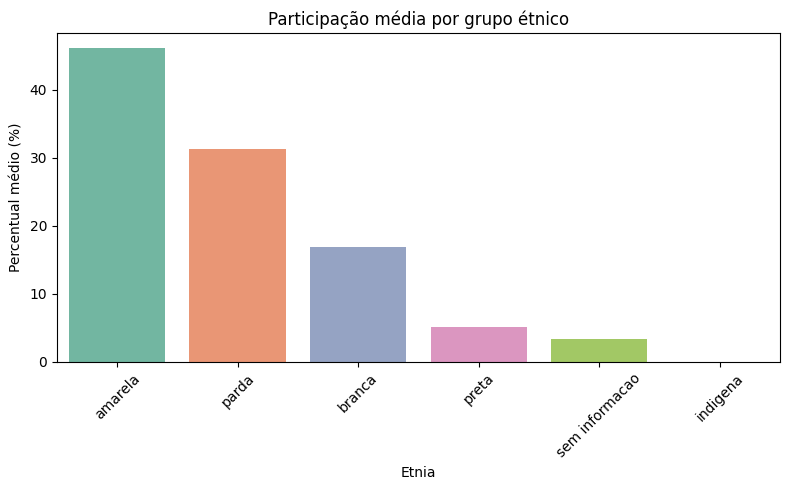

In [262]:
import matplotlib.pyplot as plt
import seaborn as sns

# Relatório resumido por etnia
relatorio_etnia = (
    etnia_porcentagem.groupby('Etnia', as_index=False)['percentual']
    .mean()
    .sort_values('percentual', ascending=False)
)

print('RESUMO POR ETNIA')
print(relatorio_etnia.to_string(index=False))

# Gráfico 1: participação média por etnia
plt.figure(figsize=(8, 5))
sns.barplot(data=relatorio_etnia, x='Etnia', y='percentual', palette='Set2')
plt.title('Participação média por grupo étnico')
plt.ylabel('Percentual médio (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### **Gráfico 2: pizza da participação por etnia**

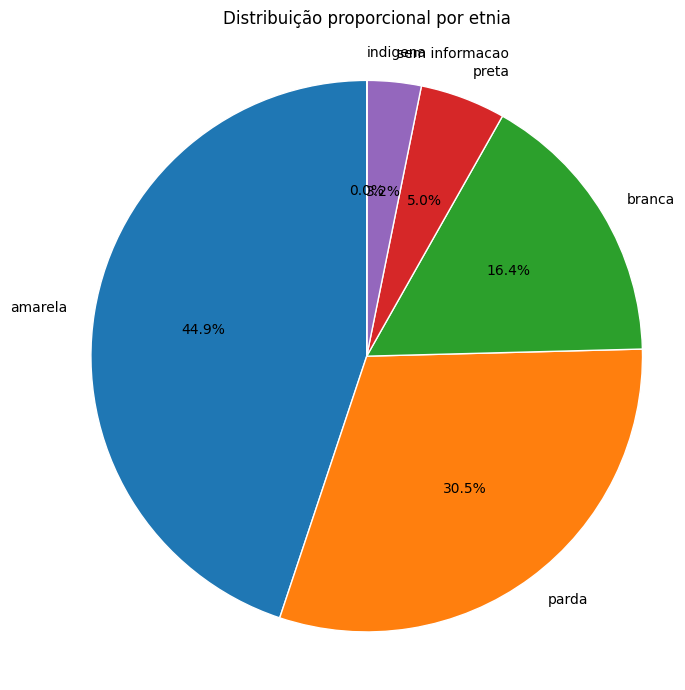

In [263]:
plt.figure(figsize=(7, 7))
plt.pie(
    relatorio_etnia['percentual'],
    labels=relatorio_etnia['Etnia'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white'}
)
plt.title('Distribuição proporcional por etnia')
plt.axis('equal')
plt.tight_layout()
plt.show()

### **Relatório resumido por faixa etária**

In [264]:
relatorio_faixa = (
    faixa_melt.groupby('Faixa_Etaria', as_index=False)['Valor']
    .sum()
    .sort_values('Valor', ascending=False)
)

print('\nRESUMO POR FAIXA ETÁRIA')
print(relatorio_faixa.to_string(index=False))


RESUMO POR FAIXA ETÁRIA
      Faixa_Etaria  Valor
entre 45 a 49 anos  20398
entre 50 a 54 anos  19644
entre 40 a 44 anos  17681
entre 55 a 59 anos  16409
entre 60 a 64 anos  11843
entre 65 a 69 anos   7797
entre 70 a 74 anos   3794
entre 35 a 39 anos   2828
entre 75 a 79 anos   1622
  acima de 79 anos    843
entre 30 a 34 anos    535
entre 25 a 29 anos    154
entre 20 a 24 anos    106
          ignorado      8
        Unnamed: 0      6


### **Gráfico 3: distribuição total por faixa etária**

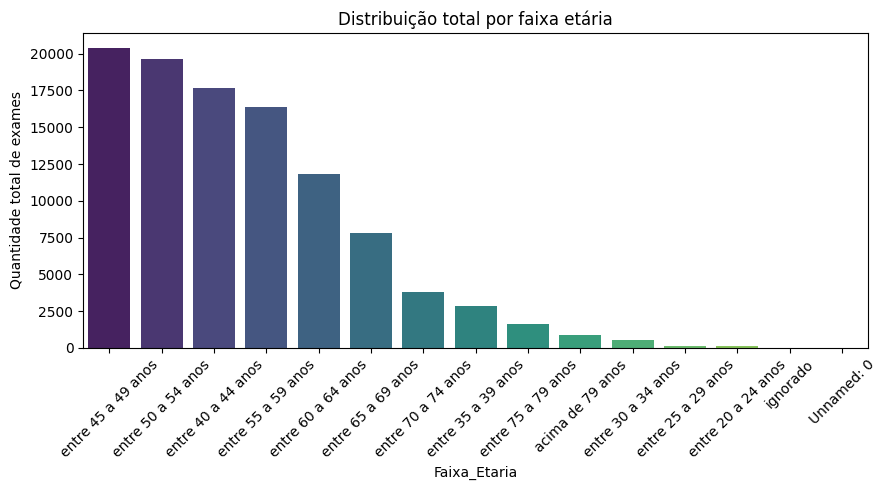

In [265]:
plt.figure(figsize=(9, 5))
sns.barplot(data=relatorio_faixa, x='Faixa_Etaria', y='Valor', palette='viridis')
plt.title('Distribuição total por faixa etária')
plt.ylabel('Quantidade total de exames')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### **Gráfico 4: boxplot por faixa etária**

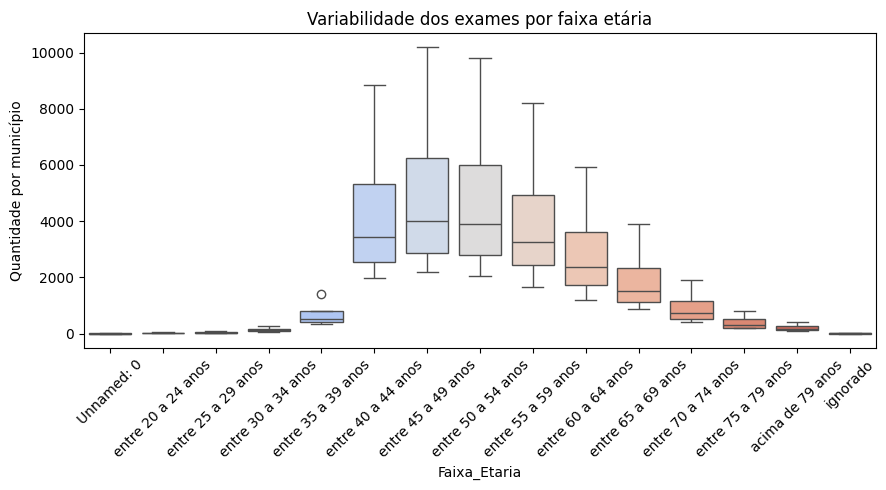

In [266]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=faixa_melt, x='Faixa_Etaria', y='Valor', palette='coolwarm')
plt.title('Variabilidade dos exames por faixa etária')
plt.ylabel('Quantidade por município')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### **Gráfico 5: comparação entre totais por município**

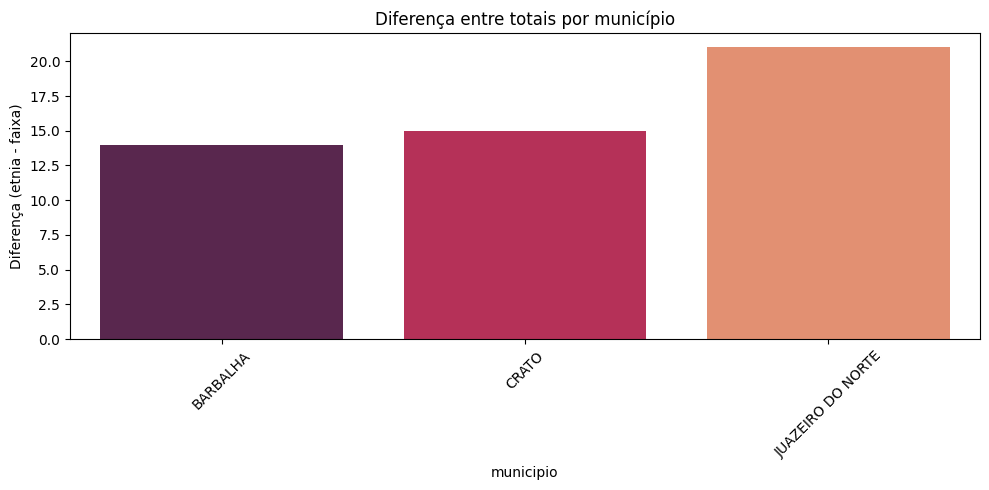

        municipio  total_etnia  total_faixa  diferenca
         BARBALHA         9398         9384         14
            CRATO        13673        13658         15
JUAZEIRO DO NORTE        21337        21316         21

COMPARAÇÃO GERAL


In [267]:
plt.figure(figsize=(10, 5))
sns.barplot(data=comparacao_total, x='municipio', y='diferenca', palette='rocket')
plt.title('Diferença entre totais por município')
plt.ylabel('Diferença (etnia - faixa)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(comparacao_total.head().to_string(index=False))
print('\nCOMPARAÇÃO GERAL')

## 1. Relatório final da análise

Esta análise consolidou a distribuição dos exames de mamografia por grupos étnicos, faixas etárias e total geral, com o objetivo de verificar a consistência entre os diferentes recortes da base. A estrutura do notebook permitiu organizar a preparação dos dados, a comparação entre categorias, a avaliação das relações entre os recortes e a geração de visualizações para apoiar a leitura dos resultados.

Os principais pontos observados ao longo da análise foram:
- a padronização e limpeza das bases para garantir consistência entre as tabelas;
- a comparação dos totais por município e entre os recortes analisados;
- a transformação dos dados para formato longo, facilitando a interpretação por grupo;
- a geração de relatórios e gráficos para resumir os padrões identificados.

## 2. Resumo da análise

A análise mostrou que a combinação de técnicas descritivas, visualização e comparação entre recortes é adequada para identificar padrões de distribuição dos exames de mamografia. A utilização de gráficos e tabelas resumidas ajuda a destacar quais categorias apresentam maior participação e quais aspectos merecem atenção na interpretação dos dados.

Em termos metodológicos, a sequência adotada foi suficiente para:
- verificar a qualidade e a consistência das bases;
- comparar distribuições entre grupos distintos;
- evidenciar a relação entre os recortes de etnia e faixa etária;
- apoiar a interpretação final com uma visão mais clara dos resultados.

## 3. Considerações finais

Os resultados obtidos indicam que a análise é promissora para compreender a distribuição dos exames, mas sua interpretação deve considerar o contexto dos dados e a possível influência de diferenças regionais, categorias incompletas ou variações entre os municípios. Portanto, recomenda-se interpretar os gráficos e os totais com cautela, especialmente ao comparar grupos com menor volume de registros.

Em conclusão, o notebook apresenta uma análise estruturada, consistente e visualmente clara, sendo uma boa base para apresentação, discussão e aprofundamento em futuras etapas do estudo.